##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_colwidth', 90)   # 2-3 line me limit
pd.set_option('display.width', 1000)        # horizontal expand, vertical shrink

**Reading the Dataset**

In [3]:
df = pd.read_csv("/content/reco_df.csv")
df.head()

,budget,title,popularity,release_year,revenue,runtime,vote_average,vote_count,cast,director,...,lang_Swedish,lang_Tamil,lang_Telugu,lang_Thai,lang_Turkish,lang_Unknown,lang_Vietnamese,status_Post Production,status_Released,status_Rumored
0,237000000,Avatar,150.437577,2009,2787965087,162.0,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,James Cameron,...,0,0,0,0,0,0,0,0,1,0
1,300000000,Pirates of the Caribbean: At World's End,139.082615,2007,961000000,169.0,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,Gore Verbinski,...,0,0,0,0,0,0,0,0,1,0
2,245000000,Spectre,107.376788,2015,880674609,148.0,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,Sam Mendes,...,0,0,0,0,0,0,0,0,1,0
3,250000000,The Dark Knight Rises,112.312950,2012,1084939099,165.0,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne Hathaway Tom Hardy,Christopher Nolan,...,0,0,0,0,0,0,0,0,1,0
4,260000000,John Carter,43.926995,2012,284139100,132.0,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Willem Dafoe Thomas Haden Church,Andrew Stanton,...,0,0,0,0,0,0,0,0,1,0


**Selecting Important Columns**

In [4]:
df.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production',
       'statu

In [9]:
print(df.columns.tolist())

['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production', 'status_Released', 

#### drop title column bcz i have original_title in this data set

In [10]:
new_df = df[['budget', 'title', 'popularity',
             'release_year', 'revenue',
             'runtime', 'vote_average',
             'vote_count', 'cast', 'director']]

In [ ]:
new_df.head()

**Understanding the Dataset**

In [11]:
new_df.shape

(4803, 10)

In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        4803 non-null   int64  
 1   title         4803 non-null   object 
 2   popularity    4803 non-null   float64
 3   release_year  4803 non-null   int64  
 4   revenue       4803 non-null   int64  
 5   runtime       4803 non-null   float64
 6   vote_average  4803 non-null   float64
 7   vote_count    4803 non-null   int64  
 8   cast          4803 non-null   object 
 9   director      4803 non-null   object 
dtypes: float64(3), int64(4), object(3)
memory usage: 375.4+ KB


**Checking Duplicate Values**

In [13]:
new_df.duplicated().sum()

np.int64(0)

**Handling Missing Values**

In [14]:
new_df.isnull().sum()

,0
budget,0
title,0
popularity,0
release_year,0
revenue,0
runtime,0
vote_average,0
vote_count,0
cast,0
director,0


In [16]:
# Fill missing values

new_df["cast"] = new_df["cast"].fillna("Not Available")
new_df["director"] = new_df["director"].fillna("Not Available")

# release_year → fill with mode
new_df["release_year"] = new_df["release_year"].fillna(new_df["release_year"].mode()[0])

# runtime → fill with median
new_df["runtime"] = new_df["runtime"].fillna(new_df["runtime"].median())

/tmp/ipykernel_8399/567727409.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["cast"] = new_df["cast"].fillna("Not Available")
/tmp/ipykernel_8399/567727409.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["director"] = new_df["director"].fillna("Not Available")
/tmp/ipykernel_8399/567727409.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [17]:
new_df.isnull().sum()

,0
budget,0
title,0
popularity,0
release_year,0
revenue,0
runtime,0
vote_average,0
vote_count,0
cast,0
director,0


**Renaming Columns**

In [18]:
new_df = new_df.rename(columns = {"original_title": "title"})
new_df = new_df.rename(columns={"release_date": "release_year"})
new_df["release_year"] = pd.to_datetime(new_df["release_year"]).dt.year.astype(int)

In [19]:
new_df.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director'], dtype='object')

In [20]:
new_df.head(3)

,budget,title,popularity,release_year,revenue,runtime,vote_average,vote_count,cast,director
0,237000000,Avatar,150.437577,1970,2787965087,162.0,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,James Cameron
1,300000000,Pirates of the Caribbean: At World's End,139.082615,1970,961000000,169.0,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,Gore Verbinski
2,245000000,Spectre,107.376788,1970,880674609,148.0,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,Sam Mendes


#### Now data has been cleaned, and it has no null values or duplicate values.

##Exploratory Data Analysis (EDA)

**Univariet analysis**

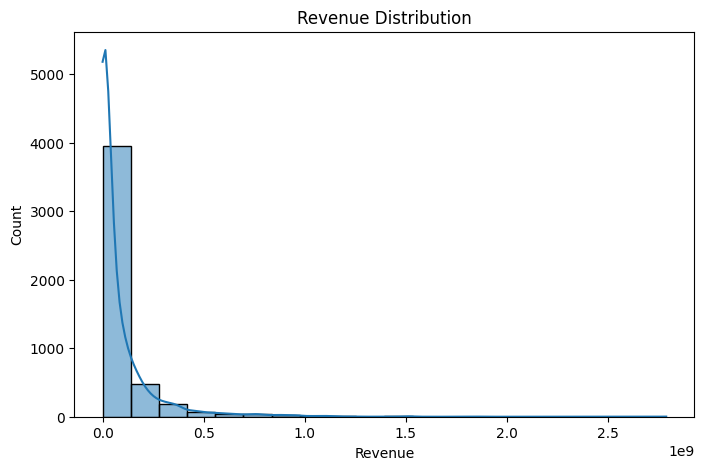

In [21]:
# From this plot, it becomes clear that most movies have low revenue, but a few big-budget movies are earning very high revenue.
plt.figure(figsize=(8,5))
sns.histplot(new_df["revenue"], bins = 20, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.show()

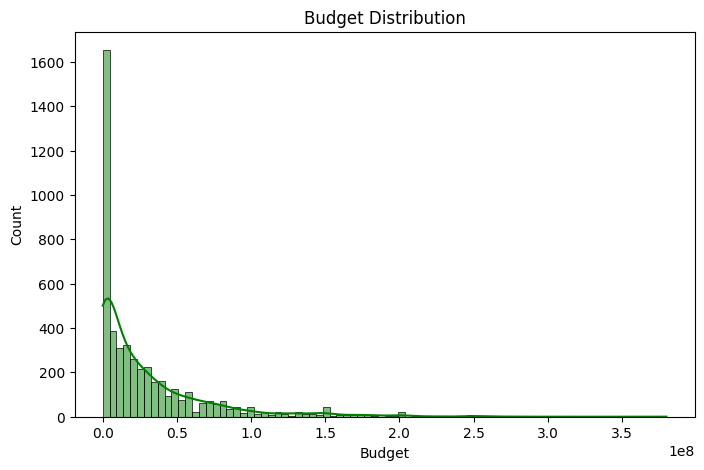

In [22]:
# High-budget movies rare hoti hain — most movies low/medium budget.
plt.figure(figsize=(8,5))
sns.histplot(new_df["budget"], kde=True, color='green')
plt.title("Budget Distribution")
plt.xlabel("Budget")
plt.show()

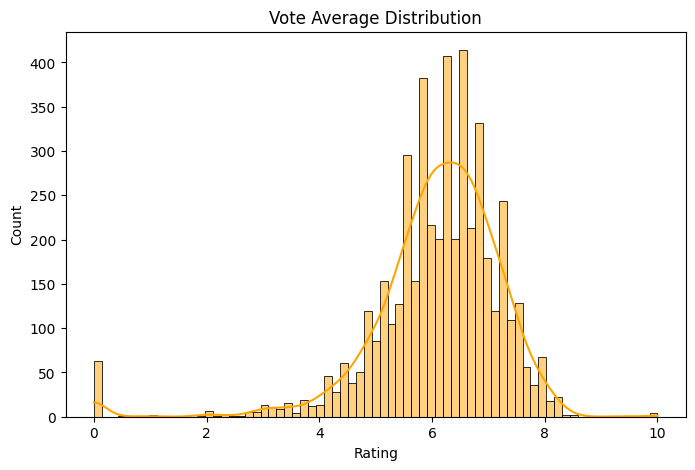

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(new_df["vote_average"], kde=True, color='orange')
plt.title("Vote Average Distribution")
plt.xlabel("Rating")
plt.show()
# Ratings mostly cluster between 5 and 8.

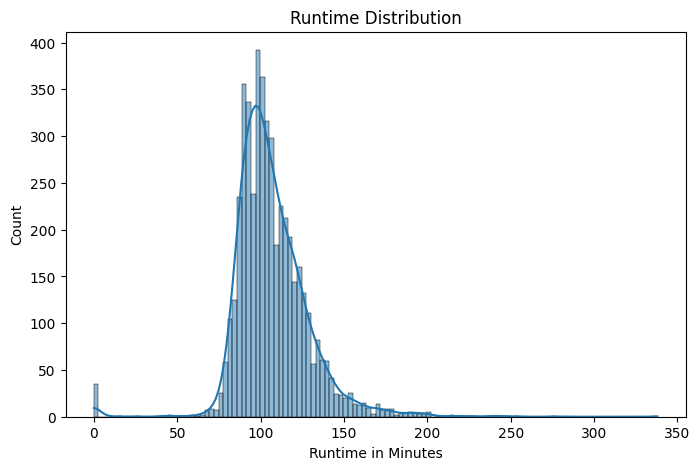

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(new_df["runtime"], kde=True)
plt.title("Runtime Distribution")
plt.xlabel("Runtime in Minutes")
plt.show()
# Most movies are around 75–150 minutes long.

### Bivariat analysis

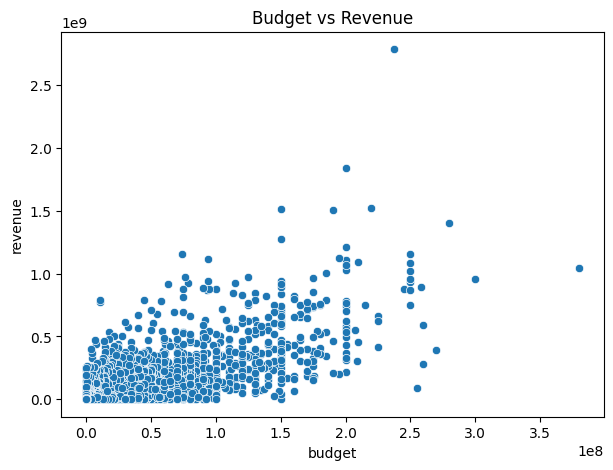

In [25]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=new_df, x="budget", y="revenue")
plt.title("Budget vs Revenue")
plt.show()
# We can see the trend — higher budget leads to higher revenue (positive correlation).

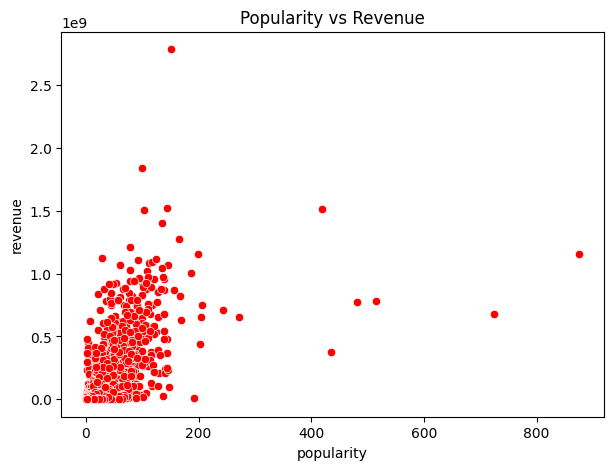

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=new_df, x="popularity", y="revenue", color='red')
plt.title("Popularity vs Revenue")
plt.show()
# Popular movies generate high revenue.

# As we can see, popular movies usually have higher revenue,
# but there are also some movies with low popularity that still earn very high revenue.

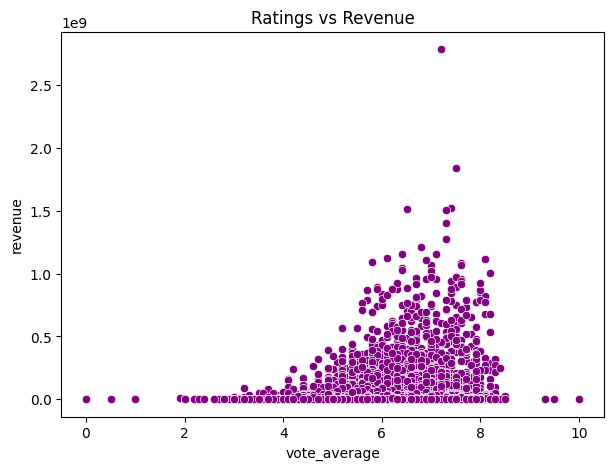

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=new_df, x="vote_average", y="revenue", color='purple')
plt.title("Ratings vs Revenue")
plt.show()
# Highly-rated movies also tend to have higher revenue.
# So, movies with ratings between 5.5 and 8.5 have very high revenue.

### Multivariat Analysis

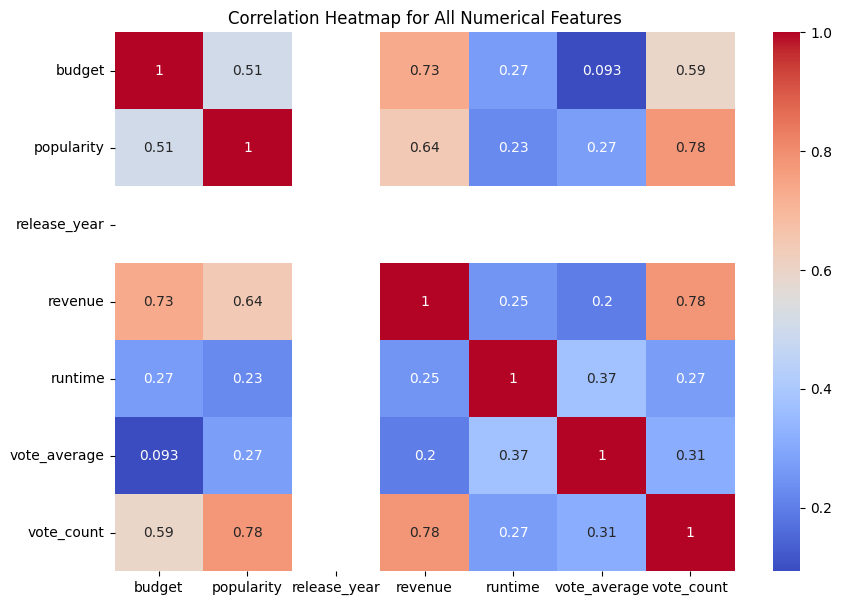

In [28]:
plt.figure(figsize=(10,7))

num_cols = new_df.select_dtypes(include=['int64', 'float64']).columns

sns.heatmap(new_df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for All Numerical Features")
plt.show()
# check the relation with revenue

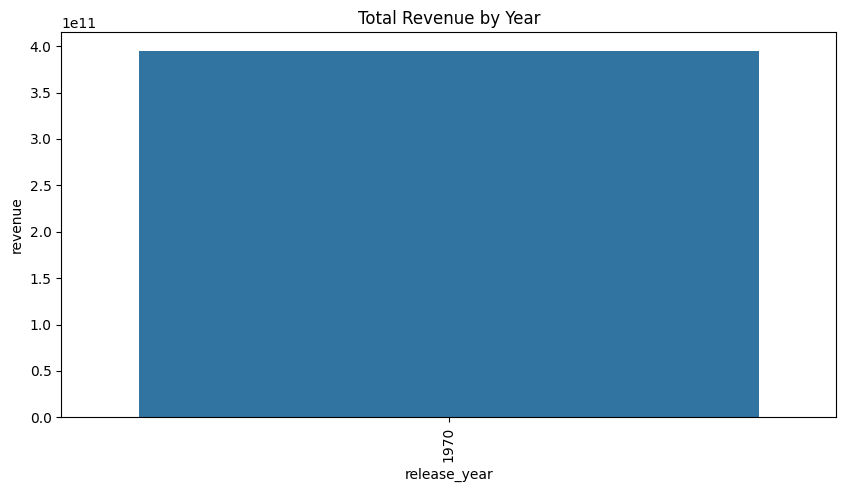

In [29]:
# Year-wise Revenue (Which year earned the most?)
yearly = new_df.groupby("release_year")["revenue"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=yearly, x="release_year", y="revenue")
plt.xticks(rotation=90)
plt.title("Total Revenue by Year")
plt.show()
# This plot will show which year’s movies earned the most.

**We have many years in the dataset, which makes the bar plot hard to interpret, so now we have taken the top 15 years with the highest total revenue**

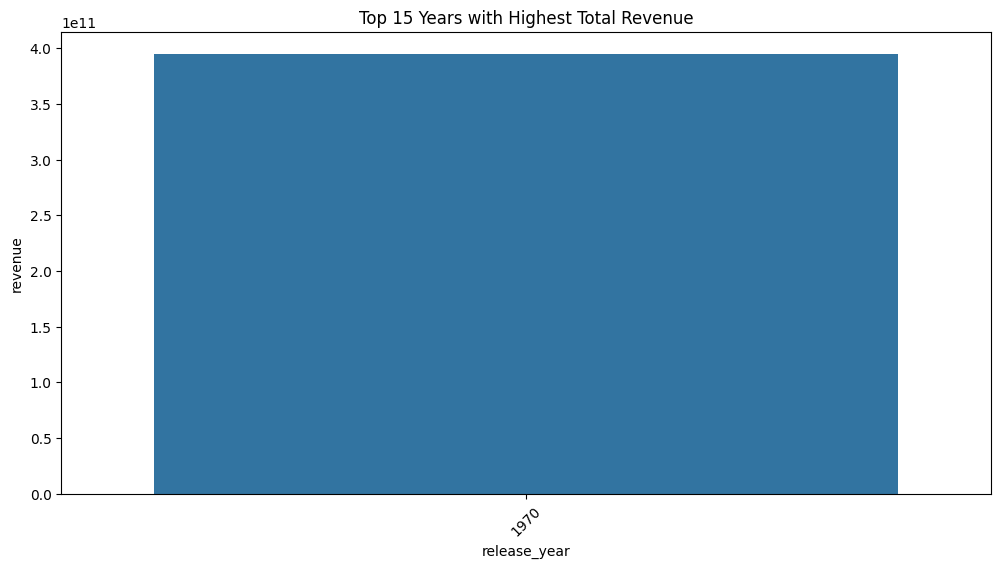

In [30]:
yearly = (
    new_df.groupby("release_year")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(data=yearly, x="release_year", y="revenue")
plt.xticks(rotation=45)
plt.title("Top 15 Years with Highest Total Revenue")
plt.show()
# le9 means billion and le6 means million is dollars

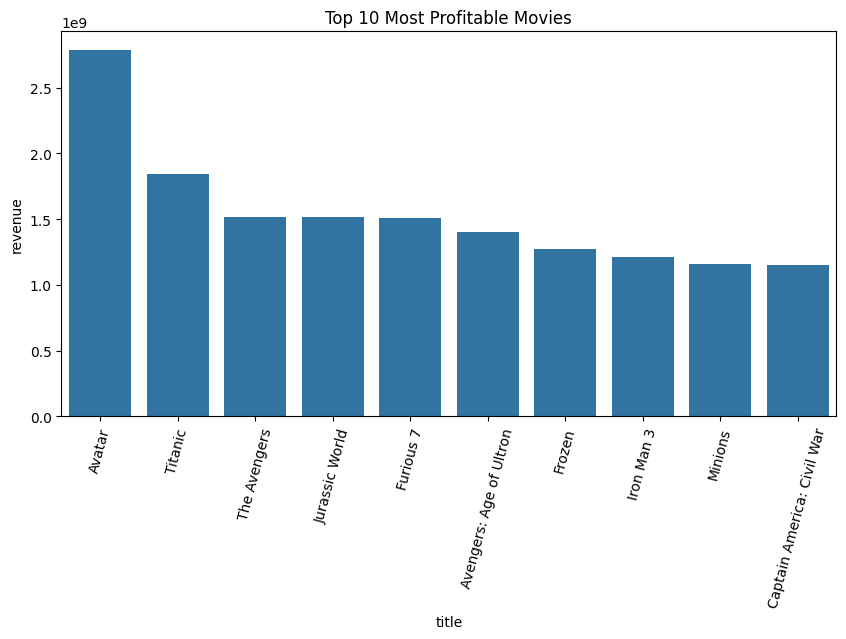

In [31]:
# Top 10 Highest Revenue Movies
top10 = new_df.sort_values("revenue", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="title", y="revenue")
plt.xticks(rotation=75)
plt.title("Top 10 Most Profitable Movies")
plt.show()

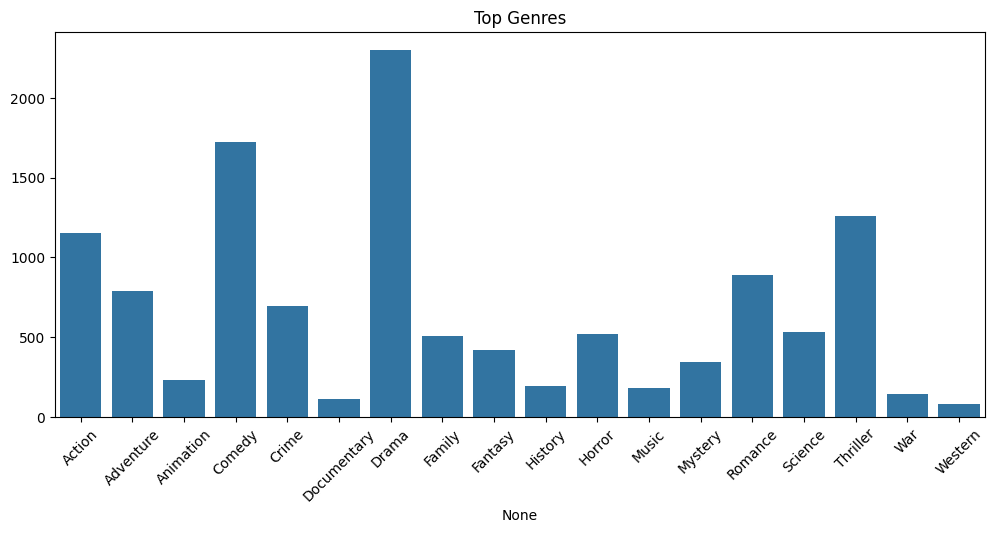

In [35]:
genre_cols = [col for col in df.columns if col in [
    'Action', 'Adventure', 'Animation', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Family',
    'Fantasy', 'History', 'Horror', 'Music',
    'Mystery', 'Romance', 'Science', 'Thriller',
    'War', 'Western'
]]

genre_counts = df[genre_cols].sum()

plt.figure(figsize=(12,5))
sns.barplot(x=genre_counts.index, y=genre_counts.values)

plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

In [37]:
language_cols = [col for col in df.columns if col.startswith('lang_')]

print(language_cols)

['lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese']


In [39]:
# 1) Create mapping dictionary
lang_map = {
    'en': 'English',
    'ja': 'Japanese',
    'fr': 'French',
    'zh': 'Chinese',
    'es': 'Spanish',
    'de': 'German',
    'hi': 'Hindi',
    'ru': 'Russian',
    'ko': 'Korean',
    'te': 'Telugu',
    'cn': 'Chinese',
    'it': 'Italian',
    'nl': 'Dutch',
    'ta': 'Tamil',
    'sv': 'Swedish',
    'th': 'Thai',
    'da': 'Danish',
    'xx': 'Unknown',
    'hu': 'Hungarian',
    'cs': 'Czech',
    'pt': 'Portuguese',
    'is': 'Icelandic',
    'tr': 'Turkish',
    'nb': 'Norwegian Bokmål',
    'af': 'Afrikaans',
    'pl': 'Polish',
    'he': 'Hebrew',
    'ar': 'Arabic',
    'vi': 'Vietnamese',
    'ky': 'Kyrgyz',
    'id': 'Indonesian',
    'ro': 'Romanian',
    'fa': 'Persian',
    'no': 'Norwegian',
    'sl': 'Slovenian',
    'ps': 'Pashto',
    'el': 'Greek'
}

In [41]:
[col for col in df.columns if col.startswith('lang_')]

['lang_Afrikaans',
 'lang_Arabic',
 'lang_Chinese',
 'lang_Czech',
 'lang_Danish',
 'lang_Dutch',
 'lang_English',
 'lang_French',
 'lang_German',
 'lang_Greek',
 'lang_Hebrew',
 'lang_Hindi',
 'lang_Hungarian',
 'lang_Icelandic',
 'lang_Indonesian',
 'lang_Italian',
 'lang_Japanese',
 'lang_Korean',
 'lang_Kyrgyz',
 'lang_Norwegian',
 'lang_Norwegian Bokmål',
 'lang_Pashto',
 'lang_Persian',
 'lang_Polish',
 'lang_Portuguese',
 'lang_Romanian',
 'lang_Russian',
 'lang_Slovenian',
 'lang_Spanish',
 'lang_Swedish',
 'lang_Tamil',
 'lang_Telugu',
 'lang_Thai',
 'lang_Turkish',
 'lang_Unknown',
 'lang_Vietnamese']

In [42]:
new_df.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director'], dtype='object')

#### Top 10 movies in English and Hindi by revenue.

In [43]:
import warnings
warnings.filterwarnings("ignore")

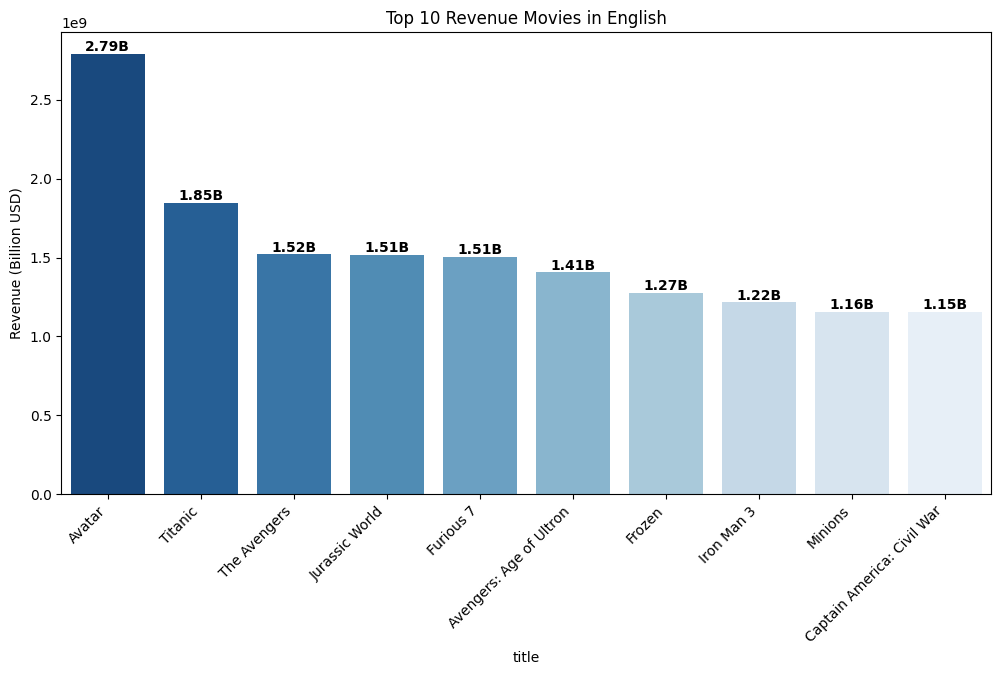

In [45]:
# Font fix for Hindi (won't affect English)
plt.rcParams['font.family'] = 'DejaVu Sans'

english_df = df[df['lang_English'] == 1]

# Top 10 revenue movies
top10_eng = english_df.nlargest(10, 'revenue')

# Plot
plt.figure(figsize=(12,6))
bar = sns.barplot(data=top10_eng, x='title', y='revenue', palette='Blues_r')

# Annotate revenue on top of bars (in Billion USD)
for p in bar.patches:
    bar.annotate(f'{p.get_height()/1e9:.2f}B',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Revenue (Billion USD)")
plt.title("Top 10 Revenue Movies in English")
plt.show()

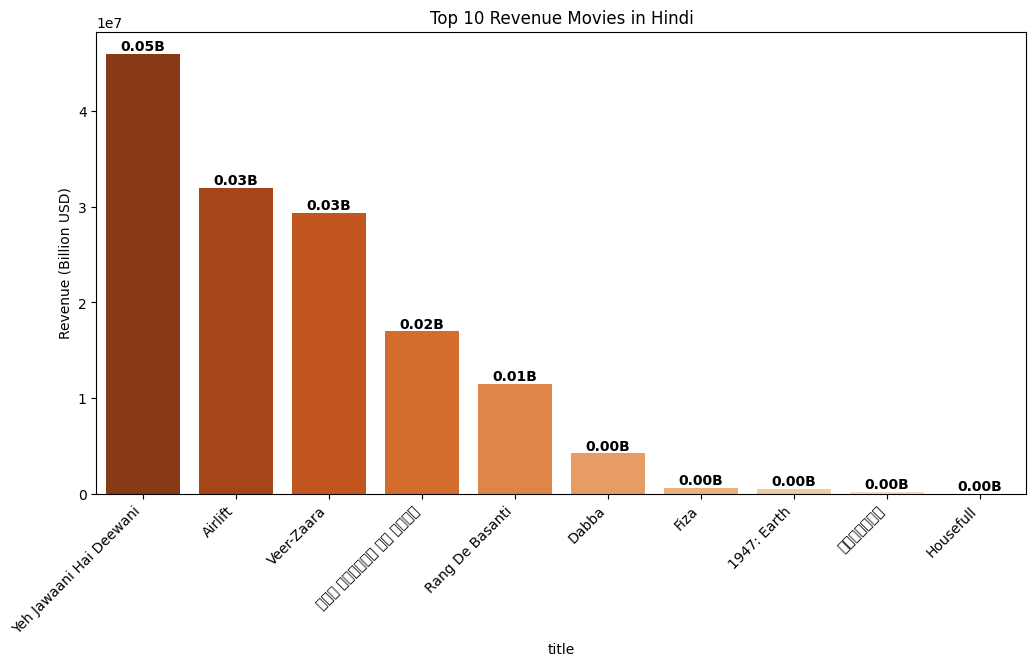

In [47]:
# Filter Hindi movies
hindi_df = df[df['lang_Hindi'] == 1]

# Top 10 revenue movies
top10_hin = hindi_df.nlargest(10, 'revenue')

# Plot
plt.figure(figsize=(12,6))
bar = sns.barplot(data=top10_hin, x='title', y='revenue', palette='Oranges_r')

# Annotate revenue on top of bars (in Billion USD)
for p in bar.patches:
    bar.annotate(f'{p.get_height()/1e9:.2f}B',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Revenue (Billion USD)")
plt.title("Top 10 Revenue Movies in Hindi")
plt.show()

#### top 10 english movies by ratings

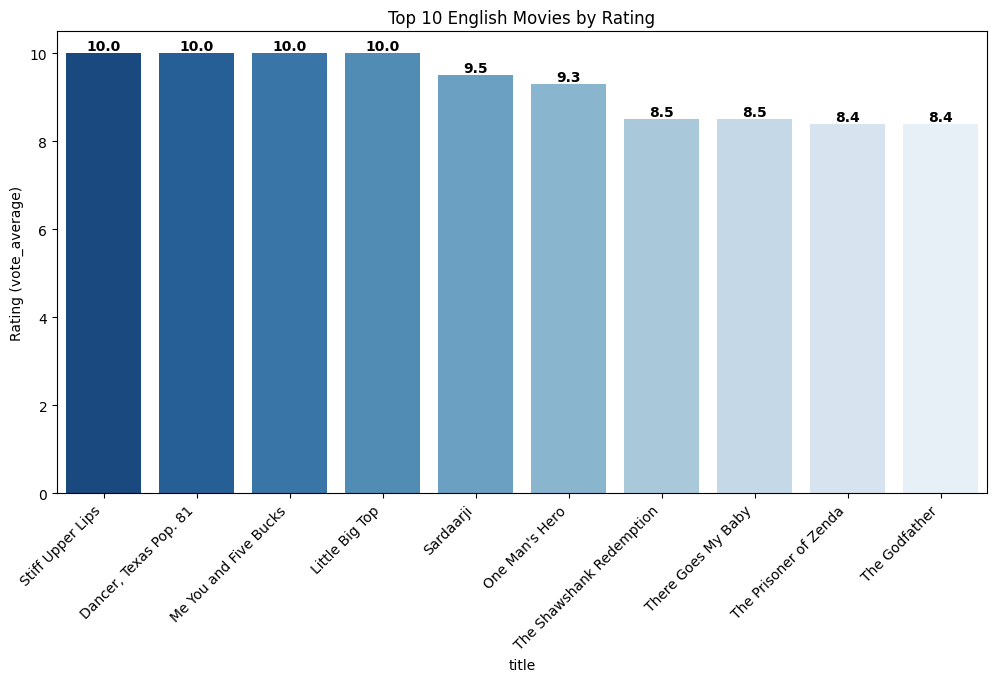

In [49]:
# Filter English movies
english_df = df[df['lang_English'] == 1]
# Top 10 movies by rating
top10_eng = english_df.nlargest(10, 'vote_average')

# Plot
plt.figure(figsize=(12,6))
bar = sns.barplot(data=top10_eng, x='title', y='vote_average', palette='Blues_r')

# Annotate rating on top of bars
for p in bar.patches:
    bar.annotate(f'{p.get_height():.1f}',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Rating (vote_average)")
plt.title("Top 10 English Movies by Rating")
plt.show()

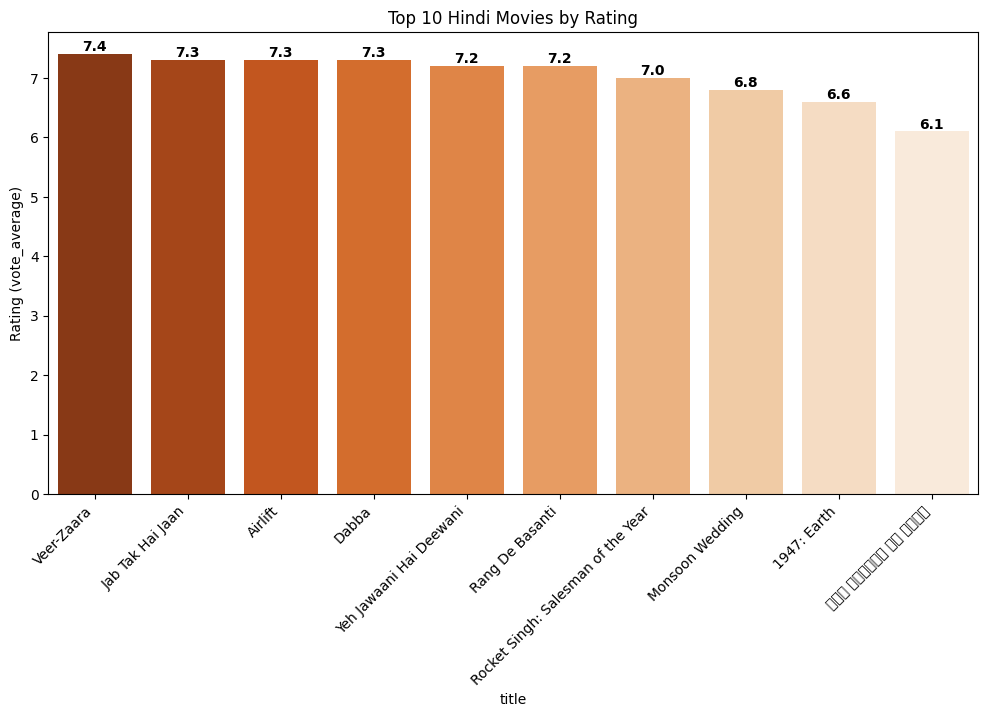

In [51]:
# Hindi Top 10 Movies by Rating
hindi_df = df[df['lang_Hindi'] == 1]
# Top 10 movies by rating
top10_hin = hindi_df.nlargest(10, 'vote_average')

# Plot
plt.figure(figsize=(12,6))
bar = sns.barplot(data=top10_hin, x='title', y='vote_average', palette='Oranges_r')

# Annotate rating on top of bars
for p in bar.patches:
    bar.annotate(f'{p.get_height():.1f}',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Rating (vote_average)")
plt.title("Top 10 Hindi Movies by Rating")
plt.show()

We are finding the Top 5 years with the highest total revenue.
For each of those 5 years:

Top English movie (highest revenue in that year)

Top Hindi movie (highest revenue in that year)

Top overall movie (highest revenue overall in that year — any language)


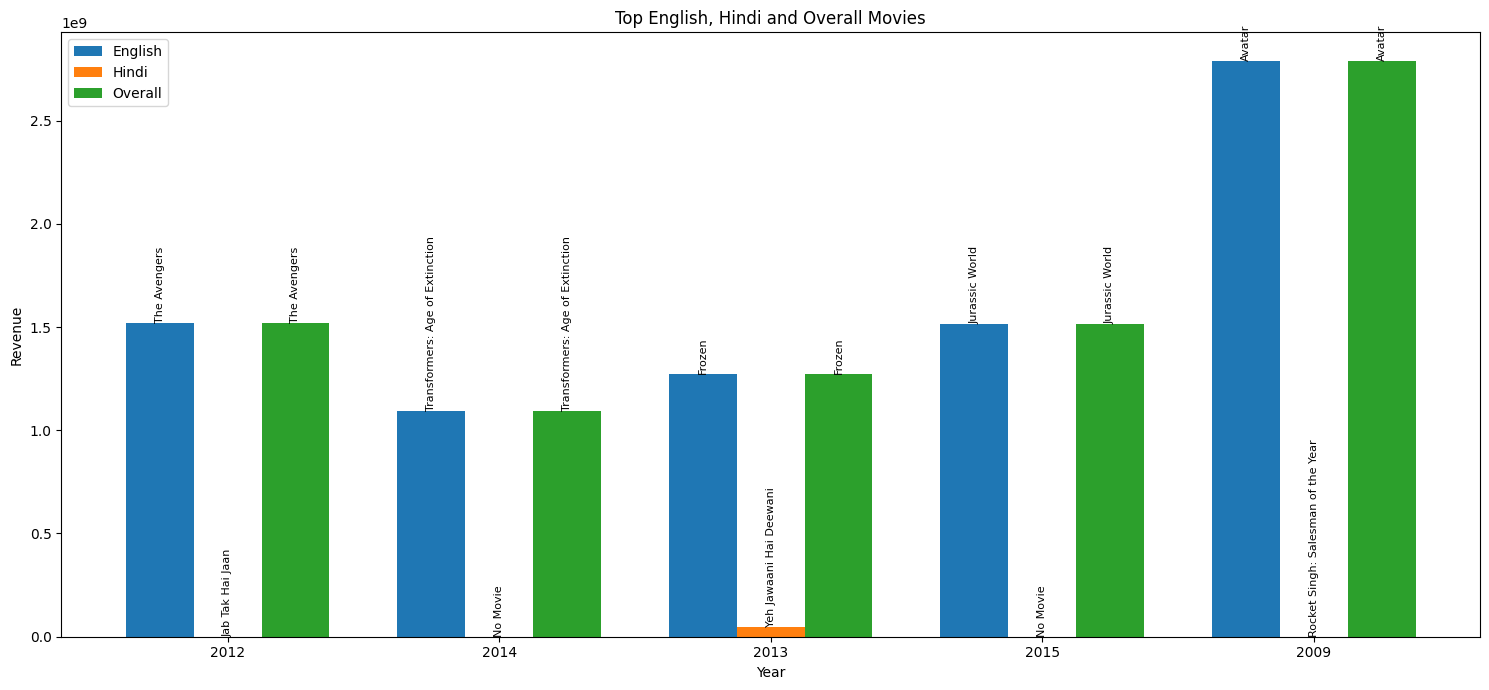

In [63]:
# 1. Top 5 revenue years
top5_years = (
    df.groupby("release_year")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# 2. Function to get top movie
def get_top_movie(year, lang=None):

    temp_df = df[df["release_year"] == year]

    # English movies
    if lang == "English":
        temp_df = temp_df[temp_df["lang_English"] == 1]

    # Hindi movies
    elif lang == "Hindi":
        temp_df = temp_df[temp_df["lang_Hindi"] == 1]

    # Empty check
    if temp_df.empty:
        return ("No Movie", 0)

    # Highest revenue movie
    row = temp_df.sort_values("revenue", ascending=False).iloc[0]

    return (row["title"], row["revenue"])


# 3. Lists
years = []

eng_rev = []
hin_rev = []
top_rev = []

eng_name = []
hin_name = []
top_name = []


# 4. Loop
for year in top5_years:

    years.append(year)

    e_name, e_rev = get_top_movie(year, "English")
    h_name, h_rev = get_top_movie(year, "Hindi")
    t_name, t_rev = get_top_movie(year)

    eng_rev.append(e_rev)
    hin_rev.append(h_rev)
    top_rev.append(t_rev)

    eng_name.append(e_name)
    hin_name.append(h_name)
    top_name.append(t_name)


# 5. Plot
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(15,7))

b1 = plt.bar(x - width, eng_rev, width, label='English')
b2 = plt.bar(x, hin_rev, width, label='Hindi')
b3 = plt.bar(x + width, top_rev, width, label='Overall')


# 6. Add labels
def add_labels(bars, names):

    for bar, name in zip(bars, names):

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            name,
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

add_labels(b1, eng_name)
add_labels(b2, hin_name)
add_labels(b3, top_name)


# 7. Final touches
plt.xticks(x, years)

plt.xlabel("Year")
plt.ylabel("Revenue")

plt.title("Top English, Hindi and Overall Movies")

plt.legend()

plt.tight_layout()

plt.show()

# group bar chart by revenue

In [64]:
new_df.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director'], dtype='object')

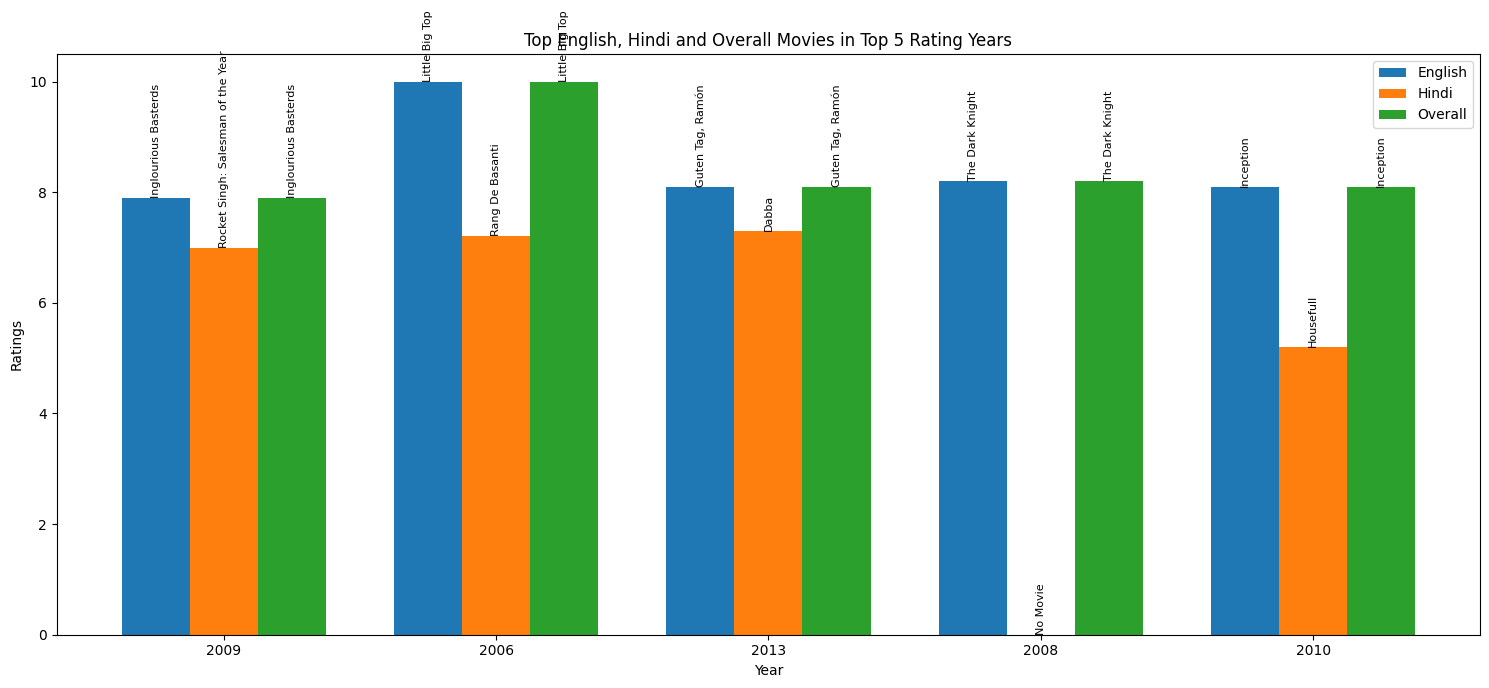

In [67]:
# 1. Top 5 rating years
top5_years = (
    df.groupby("release_year")["vote_average"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# 2. Function to get top movie
def get_top_movie(year, lang=None):

    temp_df = df[df["release_year"] == year]

    # English movies
    if lang == "English":
        temp_df = temp_df[temp_df["lang_English"] == 1]

    # Hindi movies
    elif lang == "Hindi":
        temp_df = temp_df[temp_df["lang_Hindi"] == 1]

    # Empty check
    if temp_df.empty:
        return ("No Movie", 0)

    # Highest rated movie
    row = temp_df.sort_values("vote_average", ascending=False).iloc[0]

    return (row["title"], row["vote_average"])


# 3. Lists
years = []

eng_rev = []
hin_rev = []
top_rev = []

eng_name = []
hin_name = []
top_name = []


# 4. Loop
for year in top5_years:

    years.append(year)

    e_name, e_rev = get_top_movie(year, "English")
    h_name, h_rev = get_top_movie(year, "Hindi")
    t_name, t_rev = get_top_movie(year)

    eng_rev.append(e_rev)
    hin_rev.append(h_rev)
    top_rev.append(t_rev)

    eng_name.append(e_name)
    hin_name.append(h_name)
    top_name.append(t_name)


# 5. Plot
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(15,7))

b1 = plt.bar(x - width, eng_rev, width, label='English')
b2 = plt.bar(x, hin_rev, width, label='Hindi')
b3 = plt.bar(x + width, top_rev, width, label='Overall')


# 6. Add labels
def add_labels(bars, names):

    for bar, name in zip(bars, names):

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            name,
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

add_labels(b1, eng_name)
add_labels(b2, hin_name)
add_labels(b3, top_name)


# 7. Final touches
plt.xticks(x, years)

plt.xlabel("Year")
plt.ylabel("Ratings")

plt.title("Top English, Hindi and Overall Movies in Top 5 Rating Years")

plt.legend()

plt.tight_layout()

plt.show()

### Final Clean Code — Top 10 Movies (Highest Revenue) with Budget vs Revenue

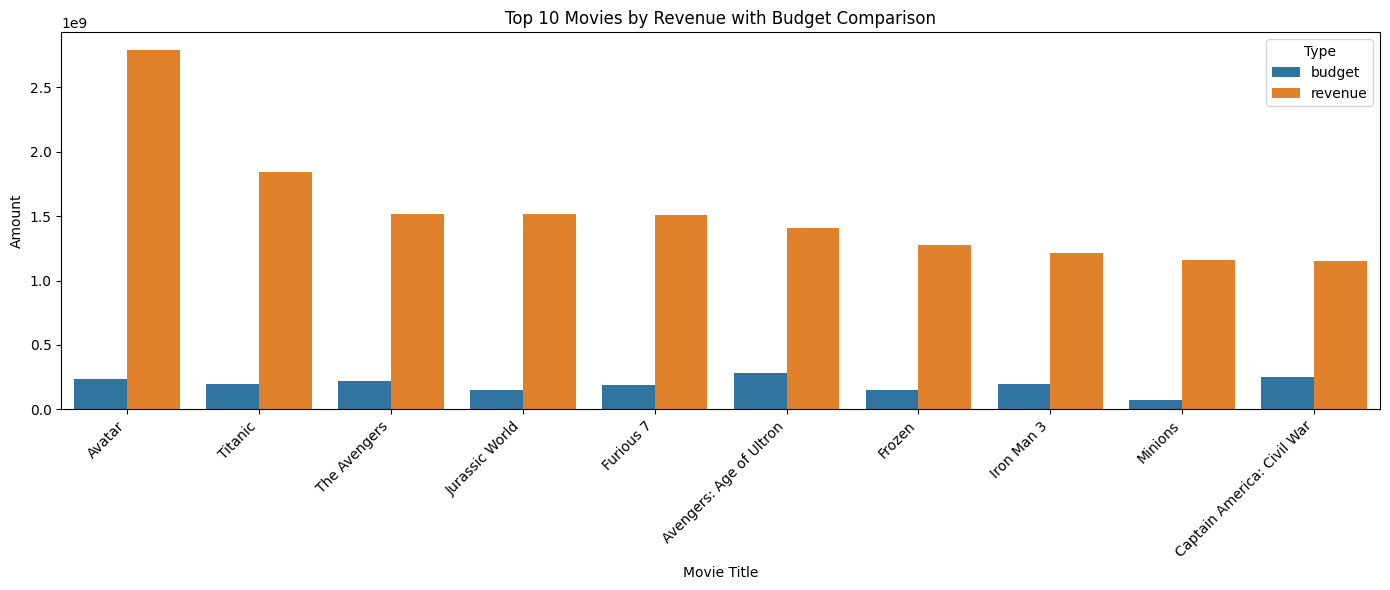

In [68]:
# Top 10 movies by revenue
top10 = new_df.nlargest(10, "revenue")[["title", "revenue", "budget"]]

# Melt the data for grouped bar chart
plot_df = top10.melt(id_vars="title", value_vars=["budget", "revenue"],
                     var_name="Type", value_name="Amount")

plt.figure(figsize=(14,6))
sns.barplot(data=plot_df, x="title", y="Amount", hue="Type")

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Movies by Revenue with Budget Comparison")
plt.ylabel("Amount")
plt.xlabel("Movie Title")
plt.tight_layout()
plt.show()

## The EDA part is done; now we will build the model.

In [69]:
new_df.head()

,budget,title,popularity,release_year,revenue,runtime,vote_average,vote_count,cast,director
0,237000000,Avatar,150.437577,1970,2787965087,162.0,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,James Cameron
1,300000000,Pirates of the Caribbean: At World's End,139.082615,1970,961000000,169.0,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,Gore Verbinski
2,245000000,Spectre,107.376788,1970,880674609,148.0,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,Sam Mendes
3,250000000,The Dark Knight Rises,112.312950,1970,1084939099,165.0,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne Hathaway Tom Hardy,Christopher Nolan
4,260000000,John Carter,43.926995,1970,284139100,132.0,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Willem Dafoe Thomas Haden Church,Andrew Stanton


## Feature Extraction

#### Now, from the genre column, I am separating all the genres and creating a new column for each genre.

---



In [70]:
df2 = new_df.copy()

In [72]:
# Copy dataframe
df2 = df.copy()

# Check dataframe
df2.head()

# Check columns
print(df2.columns)

# Shape
print(df2.shape)

# Null values
print(df2.isnull().sum())

# Duplicate values
print(df2.duplicated().sum())

# Fill missing values
df2["cast"] = df2["cast"].fillna("Not Available")
df2["director"] = df2["director"].fillna("Not Available")

# Fill release_year with mode
df2["release_year"] = df2["release_year"].fillna(
    df2["release_year"].mode()[0]
)

# Fill runtime with median
df2["runtime"] = df2["runtime"].fillna(
    df2["runtime"].median()
)

# Final check
print(df2.isnull().sum())

# Dataset preview
df2.head()

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production',
       'statu

,budget,title,popularity,release_year,revenue,runtime,vote_average,vote_count,cast,director,...,lang_Swedish,lang_Tamil,lang_Telugu,lang_Thai,lang_Turkish,lang_Unknown,lang_Vietnamese,status_Post Production,status_Released,status_Rumored
0,237000000,Avatar,150.437577,2009,2787965087,162.0,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez,James Cameron,...,0,0,0,0,0,0,0,0,1,0
1,300000000,Pirates of the Caribbean: At World's End,139.082615,2007,961000000,169.0,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stellan Skarsg\u00e5rd Chow Yun-fat,Gore Verbinski,...,0,0,0,0,0,0,0,0,1,0
2,245000000,Spectre,107.376788,2015,880674609,148.0,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux Ralph Fiennes Monica Bellucci,Sam Mendes,...,0,0,0,0,0,0,0,0,1,0
3,250000000,The Dark Knight Rises,112.312950,2012,1084939099,165.0,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne Hathaway Tom Hardy,Christopher Nolan,...,0,0,0,0,0,0,0,0,1,0
4,260000000,John Carter,43.926995,2012,284139100,132.0,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Willem Dafoe Thomas Haden Church,Andrew Stanton,...,0,0,0,0,0,0,0,0,1,0


In [73]:
df2.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production',
       'statu

In [75]:
df2.columns

Index(['budget', 'title', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'cast', 'director', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production',
       'statu

### I am dropping the object columns because they are not useful for the model, but they will be needed in the app, so I will use them there.

In [76]:
# STEP 1: Handle object columns properly
# Identify the object columns you want to keep for recommendation system
text_columns = ["title", "cast", "director"]

# Keep the original dataframe for recommendation system
reco_df = df2.copy()

# For model training, remove text columns because ML cannot use them directly
model_df = df2.drop(columns=text_columns)

In [77]:
model_df.columns

Index(['budget', 'popularity', 'release_year', 'revenue', 'runtime', 'vote_average', 'vote_count', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production', 'status_Released', 'status_Rumored'], dtyp

In [78]:
# Step 1: Split features (X) and target (y)
y = model_df["revenue"]       # output
X = model_df.drop("revenue", axis=1)   # all input features

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [81]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)

    results[name] = {"R2 Score": r2, "MAE": mae}

results


{'LinearRegression': {'R2 Score': 0.761328996344635, 'MAE': 46925313.56081847},
 'RandomForest': {'R2 Score': 0.7496422909504132, 'MAE': 37834893.9810614},
 'GradientBoosting': {'R2 Score': 0.7463891477461335,
  'MAE': 39851639.50110862},
 'SVR': {'R2 Score': -0.16434199714999131, 'MAE': 82349805.19007106},
 'KNN': {'R2 Score': 0.7682083774571902, 'MAE': 45348344.64745057}}

In [82]:
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                  R2 Score           MAE
LinearRegression  0.761329  4.692531e+07
RandomForest      0.749642  3.783489e+07
GradientBoosting  0.746389  3.985164e+07
SVR              -0.164342  8.234981e+07
KNN               0.768208  4.534834e+07


#### I evaluated multiple regression algorithms, including Linear Regression, Random Forest, Gradient Boosting, SVR, and KNN, using R² and Mean Absolute Error (MAE) as performance metrics. Although Linear Regression achieved a slightly higher R² score, indicating that it captured more overall variance in the data, its MAE was significantly higher, meaning its actual revenue predictions were farther from the true values. In contrast, the Random Forest model achieved the lowest MAE among all algorithms, demonstrating that its predictions were consistently closer to the real revenue values. Since MAE is a more reliable measure of real-world prediction accuracy—especially when working with large revenue values—the Random Forest model was chosen as the final model due to its superior error performance and better handling of non-linear patterns in the dataset.

### make new model on Random Forest

In [83]:
# Step 1: Split data
y = model_df["revenue"]
X = model_df.drop("revenue", axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
# Step 2: RF pipeline
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

In [85]:
# Step 3: Train model
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [86]:
import pickle

with open("revenue_model.pkl", "wb") as f:
    pickle.dump(rf_pipe, f)

# prediction on new input

In [87]:
X.columns

Index(['budget', 'popularity', 'release_year', 'runtime', 'vote_average', 'vote_count', 'Action', 'Adventure', 'Animation', 'Available', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Fiction', 'Foreign', 'History', 'Horror', 'Movie', 'Music', 'Mystery', 'Not', 'Romance', 'Science', 'TV', 'Thriller', 'War', 'Western', 'lang_Afrikaans', 'lang_Arabic', 'lang_Chinese', 'lang_Czech', 'lang_Danish', 'lang_Dutch', 'lang_English', 'lang_French', 'lang_German', 'lang_Greek', 'lang_Hebrew', 'lang_Hindi', 'lang_Hungarian', 'lang_Icelandic', 'lang_Indonesian', 'lang_Italian', 'lang_Japanese', 'lang_Korean', 'lang_Kyrgyz', 'lang_Norwegian', 'lang_Norwegian Bokmål', 'lang_Pashto', 'lang_Persian', 'lang_Polish', 'lang_Portuguese', 'lang_Romanian', 'lang_Russian', 'lang_Slovenian', 'lang_Spanish', 'lang_Swedish', 'lang_Tamil', 'lang_Telugu', 'lang_Thai', 'lang_Turkish', 'lang_Unknown', 'lang_Vietnamese', 'status_Post Production', 'status_Released', 'status_Rumored'], dtype='object')

In [88]:
import pickle
import pandas as pd

# Load trained model
rf = pickle.load(open("revenue_model.pkl", "rb"))

# Input (1 row dataframe)
new_input = pd.DataFrame([{
    'budget': 80000000,
    'popularity': 32.1,
    'release_year': 2020,
    'runtime': 145,
    'vote_average': 7.1,
    'vote_count': 1500,

    # Genres
    'Action': 1, 'Adventure': 0, 'Animation': 0, 'Available': 0,
    'Comedy': 0, 'Crime': 0, 'Documentary': 0, 'Drama': 1,
    'Family': 0, 'Fantasy': 0, 'Fiction': 0, 'Foreign': 0, 'History': 0,
    'Horror': 0, 'Movie': 1, 'Music': 0, 'Mystery': 0, 'Not': 0,
    'Romance': 0, 'Science': 0, 'TV': 0, 'Thriller': 1, 'War': 0, 'Western': 0,

    # Languages
    'lang_Afrikaans': 0, 'lang_Arabic': 0, 'lang_Chinese': 0, 'lang_Czech': 0,
    'lang_Danish': 0, 'lang_Dutch': 0, 'lang_English': 0, 'lang_French': 0,
    'lang_German': 0, 'lang_Greek': 0, 'lang_Hebrew': 0, 'lang_Hindi': 1,
    'lang_Hungarian': 0, 'lang_Icelandic': 0, 'lang_Indonesian': 0,
    'lang_Italian': 0, 'lang_Japanese': 0, 'lang_Korean': 0, 'lang_Kyrgyz': 0,
    'lang_Norwegian': 0, 'lang_Norwegian Bokmål': 0, 'lang_Pashto': 0,
    'lang_Persian': 0, 'lang_Polish': 0, 'lang_Portuguese': 0,
    'lang_Romanian': 0, 'lang_Russian': 0, 'lang_Slovenian': 0,
    'lang_Spanish': 0, 'lang_Swedish': 0, 'lang_Tamil': 0, 'lang_Telugu': 0,
    'lang_Thai': 0, 'lang_Turkish': 0, 'lang_Unknown': 0, 'lang_Vietnamese': 0,

    # Status
    'status_Post Production': 0,
    'status_Released': 1,
    'status_Rumored': 0
}])

# Prediction
revenue_pred = rf.predict(new_input)[0]
print("Predicted Revenue:", revenue_pred)


Predicted Revenue: 163100784.16


## The model is ready and prediction is working. Now we will write the code for the Streamlit app.

In [89]:
reco_df.to_csv("reco_df.csv", index=False)

### We will now use the model’s pickle file and the reco_df CSV file to build the recommendation app.